# Plotting a graph over time of the affilitions

In [1]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/ECTA_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced.head()

(6726, 7)


,Article_ID,Weight,Affiliation,year
0,1907032,0.5,University Of Michigan,1940
1,1906881,0.5,Wpa National Research Project,1940
2,1906882,1.0,University Of Oslo,1940
3,1906884,1.0,Princeton University,1940
4,1907032,0.5,University Of Michigan,1940


In [2]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight                    Affiliation  year       decade
0     1907032     0.5         University Of Michigan  1940  [1940,1949]
1     1906881     0.5  Wpa National Research Project  1940  [1940,1949]
2     1906882     1.0             University Of Oslo  1940  [1940,1949]
3     1906884     1.0           Princeton University  1940  [1940,1949]
4     1907032     0.5         University Of Michigan  1940  [1940,1949]
      Article_ID  Weight                Affiliation  year       decade
6721    25621405     1.0    University Of Rochester  2010  [2000,2010]
6722    25621404     0.5                  Hec Paris  2010  [2000,2010]
6723    25621403     0.5    University Of Minnesota  2010  [2000,2010]
6724    25621401     0.5  University College London  2010  [2000,2010]
6725    40928462     0.5         Harvard University  2010  [2000,2010]


# Ranking the Universities based on their number of papers per published per decade

In [3]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
Princeton University
      Article_ID  Weight           Affiliation       decade  \
201      1909271     1.0  Princeton University  [1940,1949]   
592      1907589     1.0  Princeton University  [1950,1959]   
1286     1910453     1.0  Princeton University  [1960,1969]   
2233     1914117     1.0  Princeton University  [1970,1979]   
4004     1913712     0.5  Princeton University  [1980,1989]   

      aff_cum_counts_yearly  
201                    4.00  
592                    8.00  
1286                   7.25  
2233                  12.50  
4004                  22.25  
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [4]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:12: SettingWith

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(6, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:72: SettingWi

(6, 5)
(4, 5)
(6, 5)
(6, 5)
(7, 5)
(7, 5)
(6, 5)
(5, 5)
(4, 5)
(5, 5)
(6, 5)
(7, 5)
(6, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_18339/1100585584.py:97: SettingWi

In [5]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(157, 5)
(157, 6)
      Article_ID    Weight                                     Affiliation  \
6480    25621384  1.000000                  Hebrew University Of Jerusalem   
6663    40928439  0.333333  London School Of Economics & Political Science   
6635    40664486  0.500000           Massachusetts Institute Of Technology   
6622    25621402  0.500000                             New York University   
6573    40664516  1.000000                         Northwestern University   
6617    40664517  1.000000                            Princeton University   
6619    40664519  0.333333                             Stanford University   
6615    40664491  0.125000                             Tel Aviv University   
6569    40928437  1.000000                  University Of British Columbia   
6506    40263874  0.333333              University Of California, Berkeley   
6621    25621403  0.500000           University Of California, Los Angeles   
6424    25621372  0.333333             Univers

In [6]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [7]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})
ranked

,Article_ID,Weight,Affiliation,Year Bucket,aff_cum_sum_decade,Rank
233,1907287,0.50,Columbia University,"[1940,1949]",7.500000,5.0
239,1907314,1.00,Harvard University,"[1940,1949]",11.000000,2.0
209,1907233,1.00,Massachusetts Institute Of Technology,"[1940,1949]",8.000000,4.0
121,1907133,1.00,Northwestern University,"[1940,1949]",2.000000,10.0
201,1909271,1.00,Princeton University,"[1940,1949]",4.000000,7.0
...,...,...,...,...,...,...
6623,25621401,0.50,University Of Oxford,"[2000,2010]",8.166667,14.0
6637,40664483,0.25,University Of Pennsylvania,"[2000,2010]",12.375000,11.0
6721,25621405,1.00,University Of Rochester,"[2000,2010]",3.666667,23.0
6553,25621374,0.50,University Of Wisconsin,"[2000,2010]",4.666667,21.0


In [8]:
pivot = ranked.pivot(index='Year Bucket', columns='Affiliation', values='Rank')
pivot

Affiliation,Australian National University,Carnegie Mellon University,Columbia University,Cornell University,Harvard University,Hebrew University Of Jerusalem,London School Of Economics & Political Science,Massachusetts Institute Of Technology,New York University,Northwestern University,...,"University Of California, Los Angeles","University Of California, San Diego",University Of Chicago,University Of Michigan,University Of Minnesota,University Of Oxford,University Of Pennsylvania,University Of Rochester,University Of Wisconsin,Yale University
Year Bucket,,,,,,,,,,,,,,,,,,,,,
"[1940,1949]",NaN,NaN,5.0,NaN,2.0,NaN,NaN,4.0,NaN,10.0,...,NaN,NaN,1.0,7.0,13.0,13.0,8.0,NaN,NaN,3.0
"[1950,1959]",NaN,4.0,19.0,11.0,7.0,16.0,19.0,3.0,21.0,7.0,...,12.0,NaN,10.0,9.0,20.0,8.0,15.0,15.0,19.0,1.0
"[1960,1969]",15.0,11.0,21.0,16.0,7.0,5.0,19.0,2.0,23.0,12.0,...,18.0,NaN,4.0,17.0,10.0,20.0,9.0,15.0,8.0,3.0
"[1970,1979]",12.0,13.0,17.0,22.0,1.0,8.0,4.0,7.0,23.0,3.0,...,24.0,21.0,5.0,18.0,14.0,25.0,16.0,10.0,19.0,11.0
"[1980,1989]",21.0,17.0,19.0,22.0,4.0,16.0,7.0,5.0,25.0,2.0,...,15.0,8.0,10.0,20.0,12.0,24.0,11.0,14.0,23.0,1.0
"[1990,1999]",25.0,16.0,20.0,17.0,4.0,22.0,13.0,3.0,18.0,2.0,...,9.0,10.0,5.0,21.0,14.0,19.0,8.0,11.0,23.0,1.0
"[2000,2010]",25.0,24.0,18.0,20.0,7.0,17.0,9.0,4.0,8.0,1.0,...,13.0,12.0,6.0,20.0,15.0,14.0,11.0,23.0,21.0,3.0


In [9]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",1.0,4.0,2.0,8.0,10.0,7.0,9.0,5.0,NaN,3.0
"[1950,1959]",10.0,3.0,7.0,15.0,7.0,5.0,2.0,19.0,12.0,1.0
"[1960,1969]",4.0,2.0,7.0,9.0,12.0,13.0,1.0,21.0,18.0,3.0
"[1970,1979]",5.0,7.0,1.0,16.0,3.0,15.0,2.0,17.0,24.0,11.0
"[1980,1989]",10.0,5.0,4.0,11.0,2.0,6.0,4.0,19.0,15.0,1.0
"[1990,1999]",5.0,3.0,4.0,8.0,2.0,7.0,6.0,20.0,9.0,1.0
"[2000,2010]",6.0,4.0,7.0,11.0,1.0,5.0,2.0,18.0,13.0,3.0


In [10]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Year Bucket', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",20.5,8.0,11.0,2.5,2.0,4.0,2.3,7.5,NaN,10.8
"[1950,1959]",4.8,13.0,7.0,2.0,7.0,8.0,14.2,1.5,2.7,20.3
"[1960,1969]",18.0,19.5,12.5,11.0,9.0,7.2,21.0,3.0,5.5,18.8
"[1970,1979]",25.0,23.0,34.7,11.2,28.8,12.5,30.9,10.9,4.8,16.2
"[1980,1989]",18.4,27.6,28.9,17.2,31.7,22.2,28.9,9.5,12.0,34.3
"[1990,1999]",15.3,21.9,20.7,11.9,30.8,14.2,14.4,4.9,9.9,33.5
"[2000,2010]",19.3,24.2,18.3,12.4,38.9,23.4,28.1,5.2,9.8,27.1


In [11]:

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
#invert_pivot = invert_pivot.reset_index(drop=True)
#invert_pivot = invert_pivot.drop('Year Bucket', axis=1)
invert_pivot
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/ECTA pivot.xlsx') 

/usr/local/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

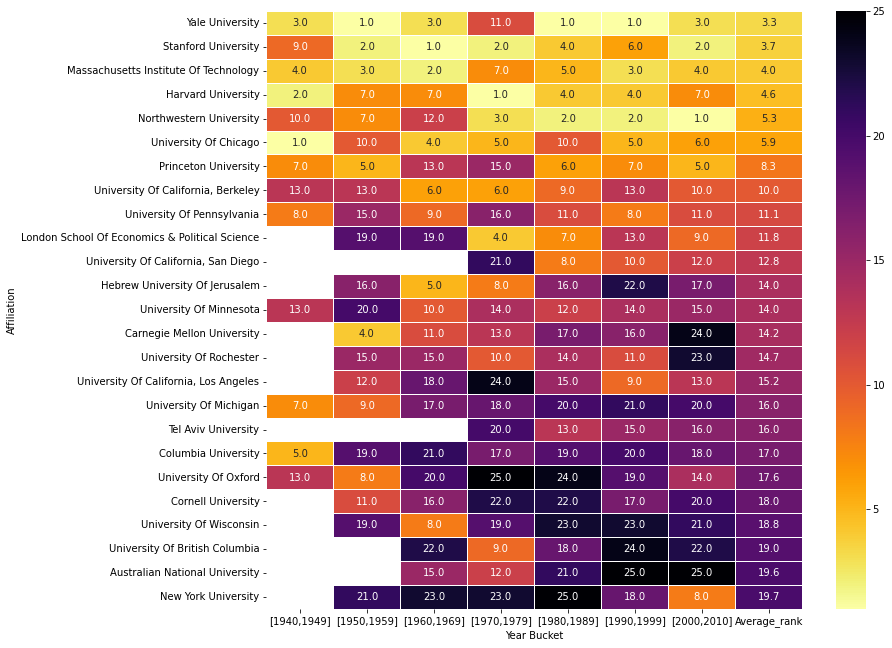

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


ranked = ranked.replace(0, '')
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)

invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)


f, ax = plt.subplots(figsize=(12, 11))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

Year Bucket                                     [1940,1949]  [1950,1959]  \
Affiliation                                                                
Australian National University                          NaN          NaN   
Carnegie Mellon University                              NaN          9.7   
Columbia University                                     7.5          1.5   
Cornell University                                      NaN          2.8   
Harvard University                                     11.0          7.0   
Hebrew University Of Jerusalem                          NaN          1.8   
London School Of Economics & Political Science          NaN          1.5   
Massachusetts Institute Of Technology                   8.0         13.0   
New York University                                     NaN          0.5   
Northwestern University                                 2.0          7.0   
Princeton University                                    4.0          8.0   
Stanford Uni

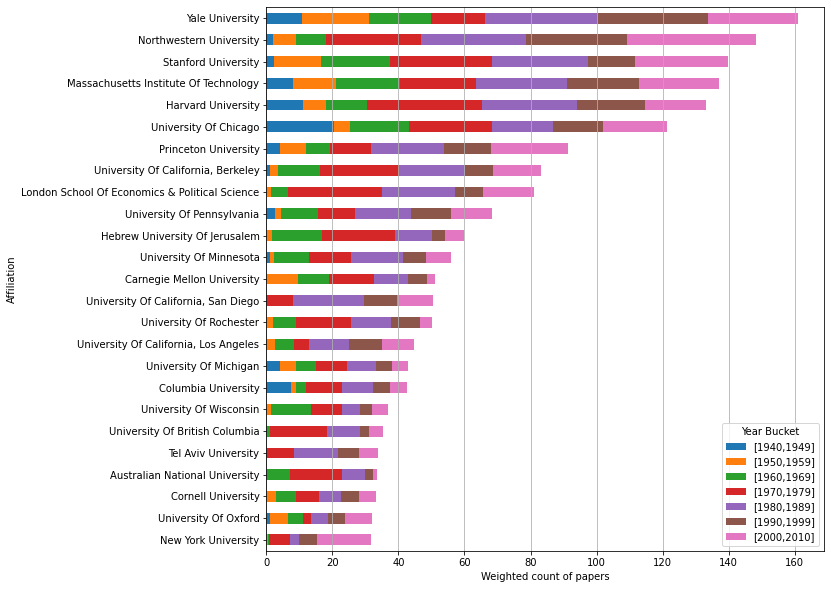

In [13]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)

ax = p.plot.barh(stacked=True, figsize=(10, 10))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
